In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

In [ ]:
#A) Hadamard Coding in CDMA

In [13]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

In [14]:
# 1. Generate three user sequences m1[n], m2[n], m3[n] of length 8 with values in {-1, 1}
np.random.seed(42) # for reproducibility

sequence_length = 8
num_users = 3

# Generate random sequences of -1 and 1
m_signals = []
for i in range(num_users):
    m_signals.append(np.random.choice([-1, 1], size=sequence_length))

m1 = m_signals[0]
m2 = m_signals[1]
m3 = m_signals[2]

print(f"User 1 signal (m1): {m1}")
print(f"User 2 signal (m2): {m2}")
print(f"User 3 signal (m3): {m3}")

User 1 signal (m1): [-1  1 -1 -1 -1  1 -1 -1]
User 2 signal (m2): [-1  1 -1 -1 -1 -1  1 -1]
User 3 signal (m3): [ 1  1  1 -1  1 -1  1  1]


In [15]:
# 2. Generate a Hadamard code of length 8
H8 = hadamard(sequence_length)

# Choose 3 orthogonal codes for the users (e.g., first 3 rows)
# In CDMA, each user is assigned a unique orthogonal code.
code1 = H8[1] # Using row 1 as code for user 1
code2 = H8[2] # Using row 2 as code for user 2
code3 = H8[3] # Using row 3 as code for user 3

print(f"Hadamard matrix H8:\n{H8}")
print(f"Code for user 1: {code1}")
print(f"Code for user 2: {code2}")
print(f"Code for user 3: {code3}")

Hadamard matrix H8:
[[ 1  1  1  1  1  1  1  1]
 [ 1 -1  1 -1  1 -1  1 -1]
 [ 1  1 -1 -1  1  1 -1 -1]
 [ 1 -1 -1  1  1 -1 -1  1]
 [ 1  1  1  1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1  1]
 [ 1  1 -1 -1 -1 -1  1  1]
 [ 1 -1 -1  1 -1  1  1 -1]]
Code for user 1: [ 1 -1  1 -1  1 -1  1 -1]
Code for user 2: [ 1  1 -1 -1  1  1 -1 -1]
Code for user 3: [ 1 -1 -1  1  1 -1 -1  1]


In [16]:
# 3. Encode the signals m1[n], m2[n], m3[n]
# Each bit of the user's data sequence is spread by the Hadamard code.
# This means if a data bit is 1, the code sequence is transmitted.
# If a data bit is -1, the inverted code sequence is transmitted.

# For simplicity, we are assuming a direct multiplication where m[n] is a sequence of bits.
# In a real system, each 'bit' of m[n] (which is -1 or 1) would modulate the entire code sequence.
# Here, we'll perform element-wise multiplication for the entire sequence's length.
# This is a simplified model, where the entire sequence m_i is spread by the code_i.

coded_signal_1 = m1 * code1
coded_signal_2 = m2 * code2
coded_signal_3 = m3 * code3

print(f"Coded signal for user 1: {coded_signal_1}")
print(f"Coded signal for user 2: {coded_signal_2}")
print(f"Coded signal for user 3: {coded_signal_3}")

Coded signal for user 1: [-1 -1 -1  1 -1 -1 -1  1]
Coded signal for user 2: [-1  1  1  1 -1 -1 -1  1]
Coded signal for user 3: [ 1 -1 -1 -1  1  1 -1  1]


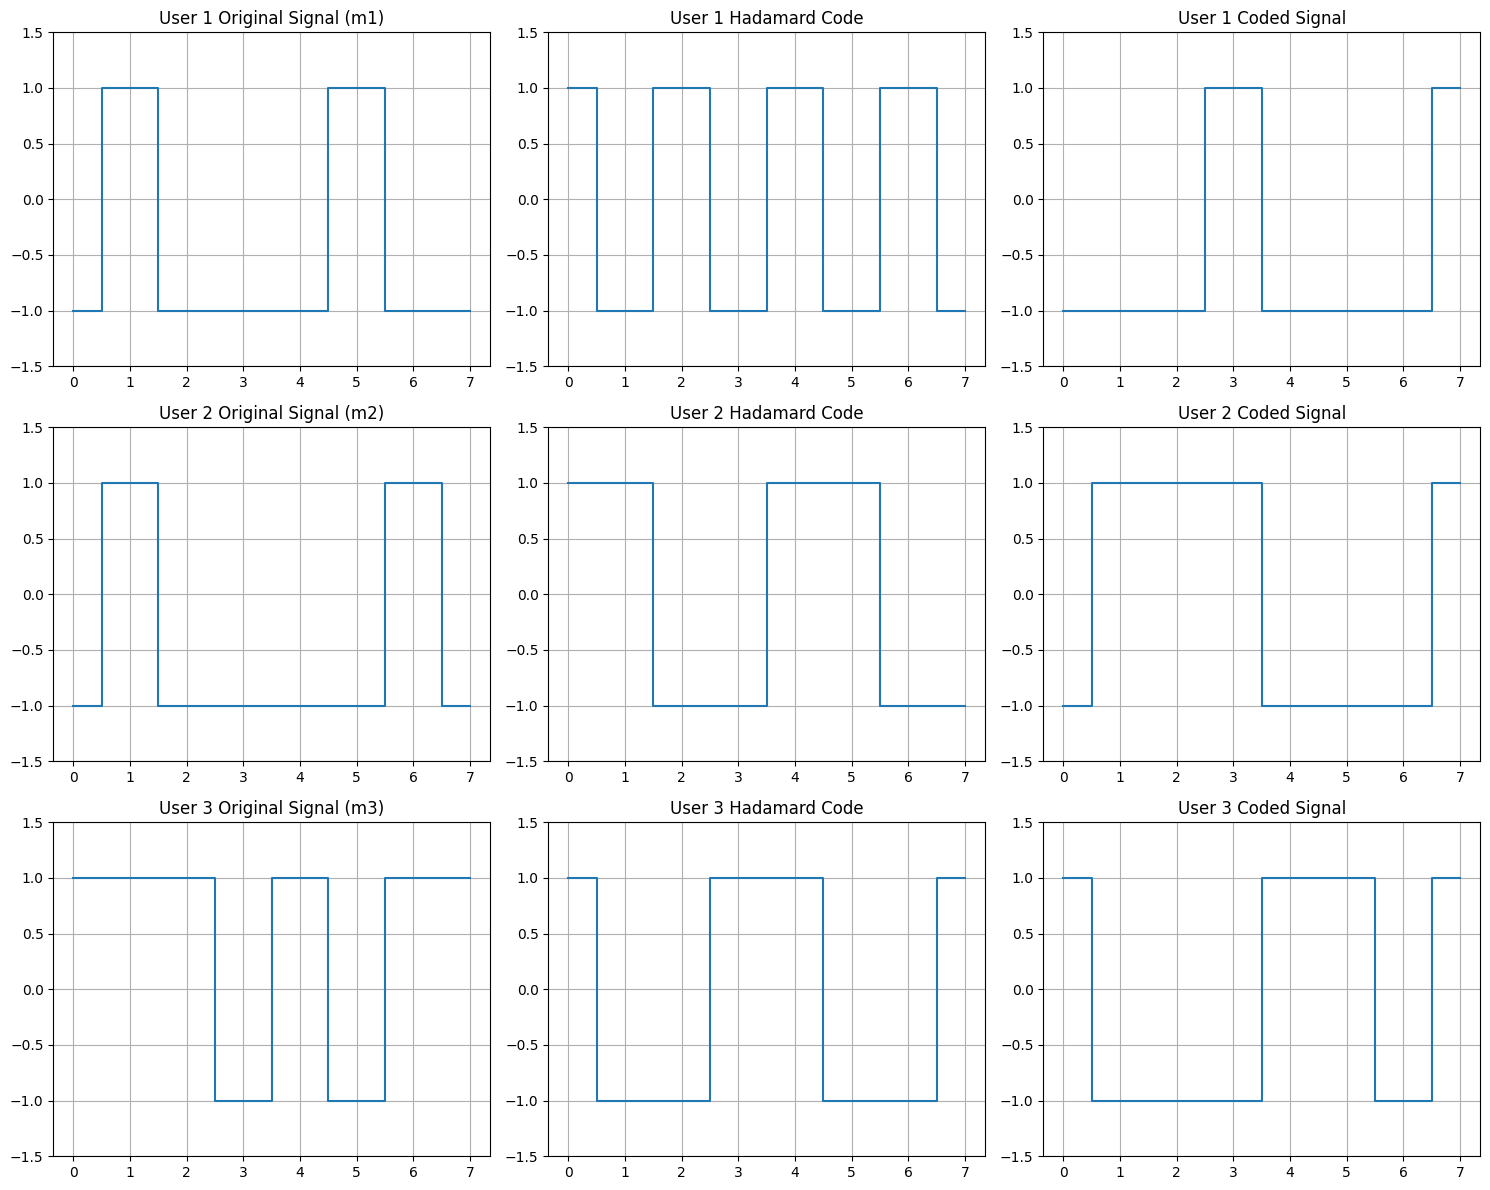

In [17]:
# 4. Plot the original signal, its code, and the coded signal for each user

plt.figure(figsize=(15, 12))

# User 1
plt.subplot(3, 3, 1)
plt.step(range(sequence_length), m1, where='mid')
plt.title('User 1 Original Signal (m1)')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 2)
plt.step(range(sequence_length), code1, where='mid')
plt.title('User 1 Hadamard Code')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 3)
plt.step(range(sequence_length), coded_signal_1, where='mid')
plt.title('User 1 Coded Signal')
plt.ylim(-1.5, 1.5)
plt.grid(True)

# User 2
plt.subplot(3, 3, 4)
plt.step(range(sequence_length), m2, where='mid')
plt.title('User 2 Original Signal (m2)')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 5)
plt.step(range(sequence_length), code2, where='mid')
plt.title('User 2 Hadamard Code')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 6)
plt.step(range(sequence_length), coded_signal_2, where='mid')
plt.title('User 2 Coded Signal')
plt.ylim(-1.5, 1.5)
plt.grid(True)

# User 3
plt.subplot(3, 3, 7)
plt.step(range(sequence_length), m3, where='mid')
plt.title('User 3 Original Signal (m3)')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 8)
plt.step(range(sequence_length), code3, where='mid')
plt.title('User 3 Hadamard Code')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.subplot(3, 3, 9)
plt.step(range(sequence_length), coded_signal_3, where='mid')
plt.title('User 3 Coded Signal')
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.tight_layout()
plt.show()

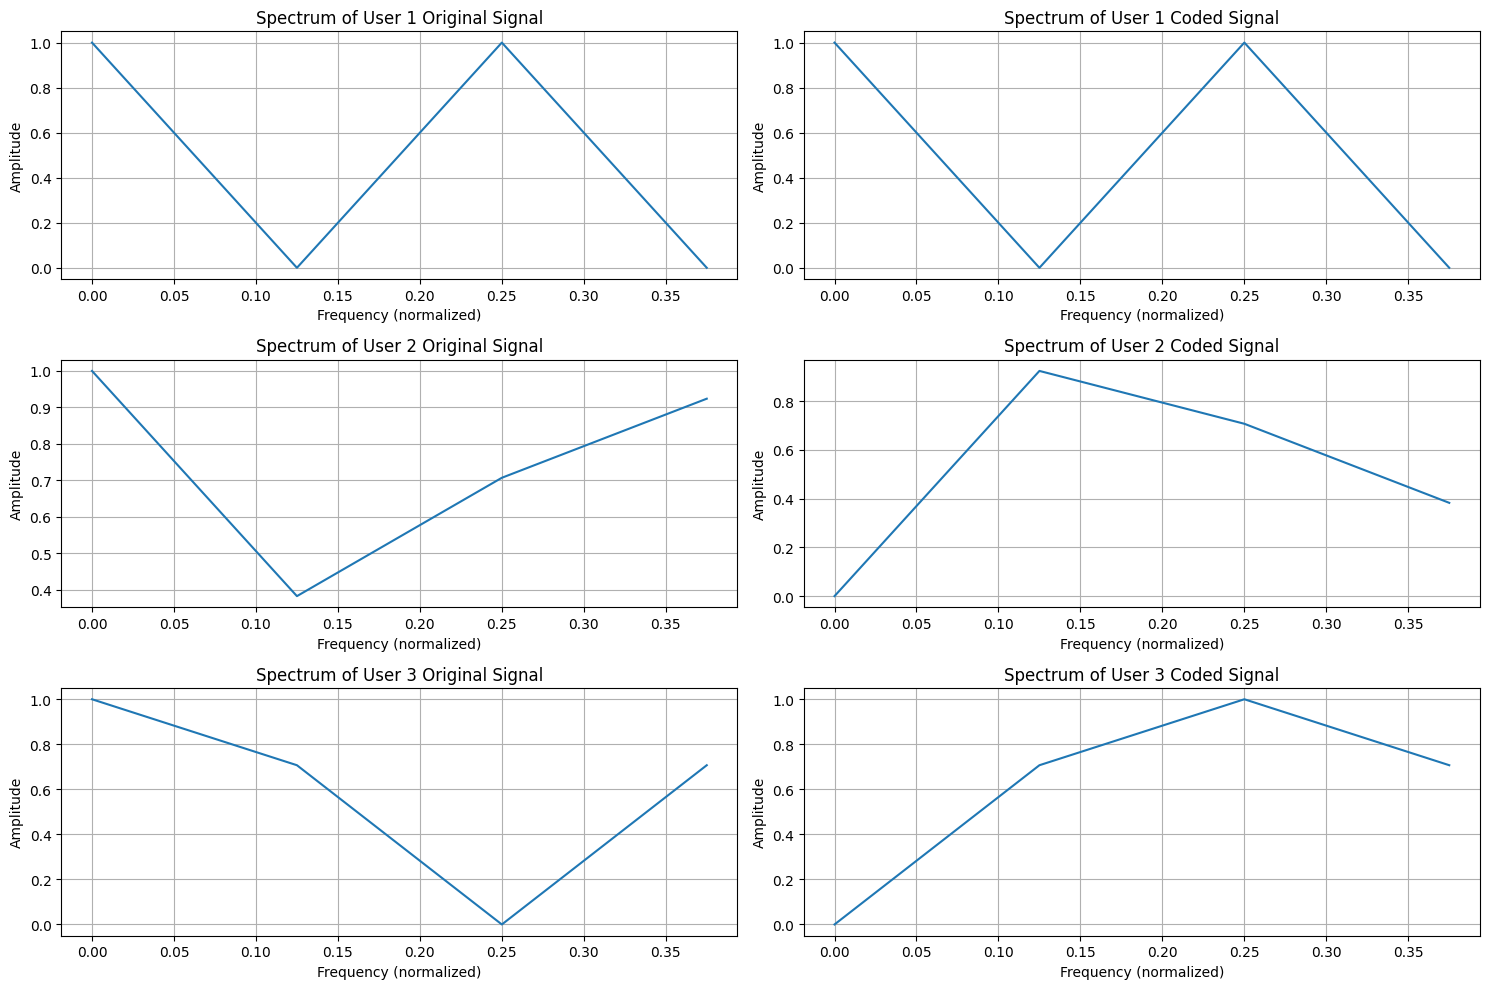

In [18]:
# 5. Show the spectrum of original signals and coded signals

def plot_spectrum(signal, title, subplot_pos, N):
    # Perform FFT
    yf = np.fft.fft(signal)
    xf = np.fft.fftfreq(N, 1) # Frequencies for a sampling rate of 1

    plt.subplot(subplot_pos)
    plt.plot(xf[:N//2], 2.0/N * np.abs(yf[0:N//2]))
    plt.title(title)
    plt.xlabel('Frequency (normalized)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.figure(figsize=(15, 10))

# User 1
plot_spectrum(m1, 'Spectrum of User 1 Original Signal', 321, sequence_length)
plot_spectrum(coded_signal_1, 'Spectrum of User 1 Coded Signal', 322, sequence_length)

# User 2
plot_spectrum(m2, 'Spectrum of User 2 Original Signal', 323, sequence_length)
plot_spectrum(coded_signal_2, 'Spectrum of User 2 Coded Signal', 324, sequence_length)

# User 3
plot_spectrum(m3, 'Spectrum of User 3 Original Signal', 325, sequence_length)
plot_spectrum(coded_signal_3, 'Spectrum of User 3 Coded Signal', 326, sequence_length)

plt.tight_layout()
plt.show()

In [ ]:
#B) Received Signal with AWGN

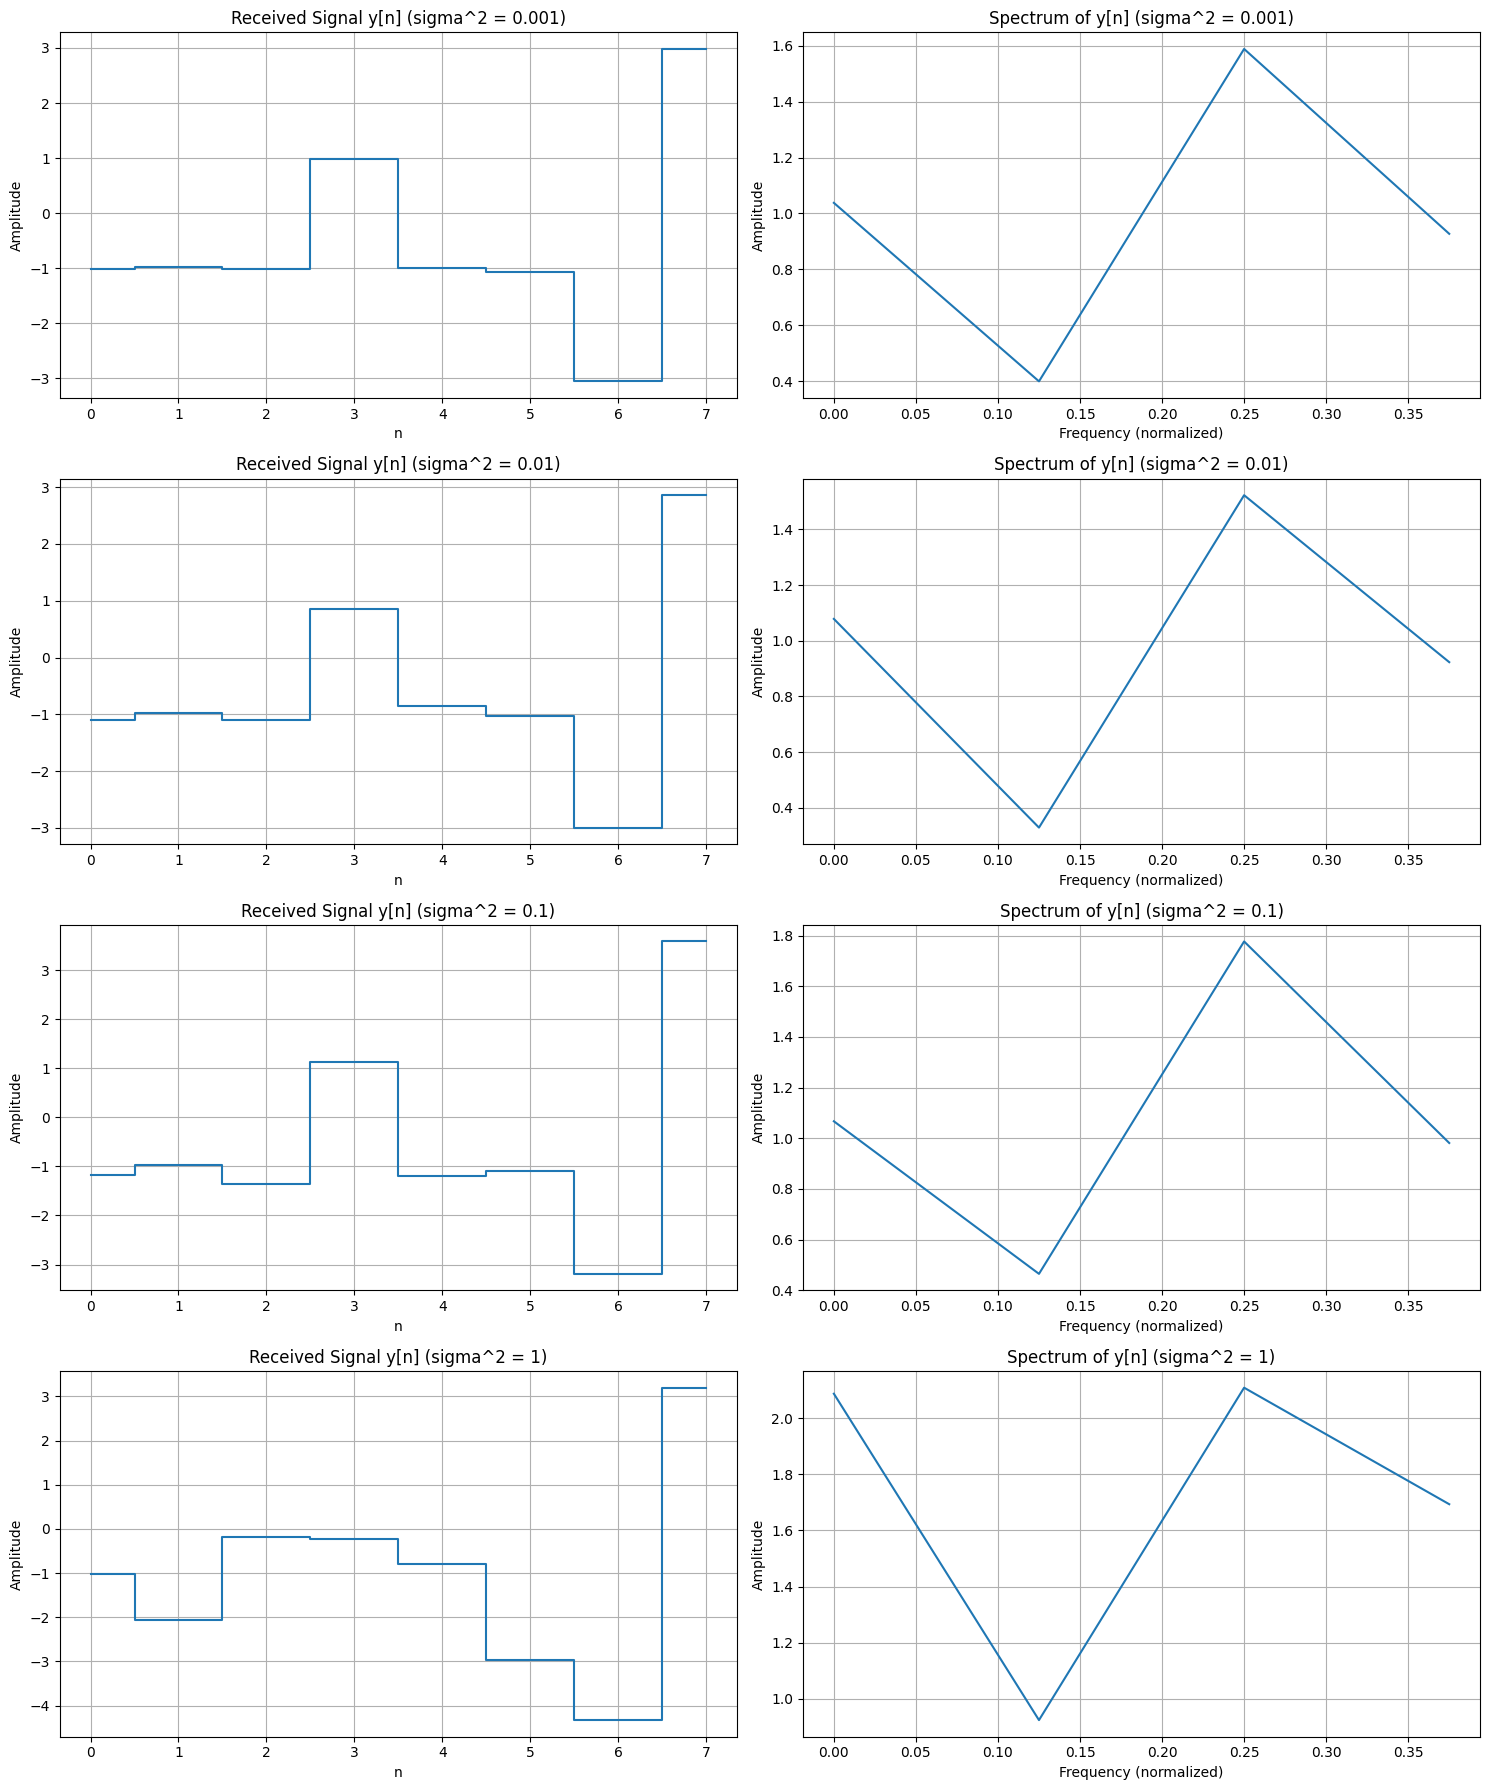

In [19]:
# 6. Construct the received signal y[n] = x1[n] + x2[n] + x3[n] + w[n]

# Sum of coded signals (x1[n] + x2[n] + x3[n])
sum_coded_signals = coded_signal_1 + coded_signal_2 + coded_signal_3

# Define noise variances
sigma2_values = [1e-3, 1e-2, 1e-1, 1]

plt.figure(figsize=(15, 18))

# Loop through different noise variances
for i, sigma2 in enumerate(sigma2_values):
    sigma = np.sqrt(sigma2)
    # Generate AWGN w[n] ~ N(0, sigma^2)
    w = np.random.normal(0, sigma, size=sequence_length)

    # Calculate received signal y[n]
    y = sum_coded_signals + w

    # Calculate subplot positions for current iteration
    rows = len(sigma2_values)
    cols = 2
    time_plot_num = 2*i + 1
    spectrum_plot_num = 2*i + 2

    # Plot y[n]
    plt.subplot(rows, cols, time_plot_num)
    plt.step(range(sequence_length), y, where='mid')
    plt.title(f'Received Signal y[n] (sigma^2 = {sigma2})')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.grid(True)

    # Plot spectrum of y[n]
    # Convert (rows, cols, plot_num) to a single three-digit integer for plot_spectrum
    plot_spectrum(y, f'Spectrum of y[n] (sigma^2 = {sigma2})', rows*100 + cols*10 + spectrum_plot_num, sequence_length)

plt.tight_layout()
plt.show()

### (c) Recovering $m_k[n]$ from $y[n]$ and the impact of $w[n]$ on $\hat{m}_k[n]$ (Mathematical Derivation)

Let's use vectorial notation to show how to recover $m_k[n]$ from the received signal $y[n]$ and analyze the impact of the noise $w[n]$.

We have $N$ users, and for each user $k$, an original signal $m_k$ (a vector of length $L$) and an orthogonal Hadamard code $c_k$ (a vector of length $L$). In our specific case, $N=3$ and $L=8$.

The coded signal for user $k$ is given by $x_k[n] = m_k[n] \cdot c_k[n]$. However, this is a simplified model. In a typical CDMA system, each *bit* of $m_k$ is spread by the *entire* code $c_k$. If $m_k[j]$ is the $j$-th bit of user $k$'s data, then the transmitted sequence for that bit is $m_k[j] \cdot c_k$. For simplicity and consistency with the previous problem parts, we'll maintain the element-wise multiplication $x_k[n] = m_k[n] \cdot c_k[n]$, where $m_k[n]$ represents a sequence of information symbols (or bits).

The received signal $y[n]$ is the sum of all coded signals plus Additive White Gaussian Noise (AWGN) $w[n]$:

$$y[n] = \sum_{k=1}^{N} x_k[n] + w[n]$$

Substituting $x_k[n] = m_k[n] \cdot c_k[n]$:

$$y[n] = \sum_{k=1}^{N} m_k[n] \cdot c_k[n] + w[n]$$

In vectorial notation, where $m_k$, $c_k$, $w$, and $y$ are vectors of length $L$ (in our case, $L=8$):

$$\mathbf{y} = \sum_{k=1}^{N} \mathbf{m}_k \odot \mathbf{c}_k + \mathbf{w}$$

where $\odot$ denotes the element-wise (Hadamard) product.

To recover the signal for a specific user, say user $j$, the receiver despreads the received signal $\mathbf{y}$ using user $j$'s code $\mathbf{c}_j$. This is typically done by taking the inner product of $\mathbf{y}$ with $\mathbf{c}_j$, or in a sequence-wise context, by element-wise multiplication and then summing, or by applying the Hadamard transform if the entire sequence is treated as one block.

Let's assume we are trying to estimate the original signal $\mathbf{m}_j$. The despreading operation involves multiplying the received signal $\mathbf{y}$ by the user's code $\mathbf{c}_j$ and then summing (or averaging) the result. This effectively correlates the received signal with the desired user's code.

The estimated signal for user $j$, denoted as $\hat{\mathbf{m}}_j$, can be obtained by:

$$\hat{\mathbf{m}}_j = \frac{1}{L} \left( \mathbf{y} \odot \mathbf{c}_j \right)$$

This is an element-wise product followed by scaling. Let's look at a single element $n$ of the estimated signal $\hat{m}_j[n]$:

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} y[i] \cdot c_j[i]$$

Substituting the expression for $y[i]$:

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} \left( \sum_{k=1}^{N} m_k[i] \cdot c_k[i] + w[i] \right) \cdot c_j[i]$$

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} \left( \sum_{k=1}^{N} m_k[i] \cdot c_k[i] \cdot c_j[i] + w[i] \cdot c_j[i] \right)$$

We can separate the sums:

$$\hat{m}_j[n] = \frac{1}{L} \sum_{i=1}^{L} \sum_{k=1}^{N} m_k[i] \cdot c_k[i] \cdot c_j[i] + \frac{1}{L} \sum_{i=1}^{L} w[i] \cdot c_j[i]$$

Now, let's focus on the first term. We can swap the order of summation:

$$\frac{1}{L} \sum_{k=1}^{N} \sum_{i=1}^{L} m_k[i] \cdot c_k[i] \cdot c_j[i]$$

Since Hadamard codes are orthogonal, their inner product is zero for different codes and $L$ for the same code:

$$\sum_{i=1}^{L} c_k[i] \cdot c_j[i] = \begin{cases} L & \text{if } k=j \\ 0 & \text{if } k \neq j \end{cases}$$

Therefore, for $k=j$, the inner product is $L$. For $k \neq j$, it's $0$.  In our simplified element-wise multiplication model, we are not taking a direct inner product over the entire sequence. Instead, let's consider the orthogonality property for $c_k[i] \cdot c_j[i]$. When $k \neq j$, the sequence $c_k[i] \cdot c_j[i]$ should ideally average to zero over the length $L$.

Let's assume the codes are normalized such that $\frac{1}{L} \sum_{i=1}^{L} c_k[i] c_j[i] = \delta_{kj}$, where $\delta_{kj}$ is the Kronecker delta (1 if $k=j$, 0 otherwise). In the context of element-wise multiplication, this assumption simplifies the recovery.

Let's reconsider the product $c_k[i] \cdot c_j[i]$. Since $c_k[i]$ and $c_j[i]$ are either 1 or -1, their product is also 1 or -1. The orthogonality means that if we multiply the received signal by $c_j[n]$, the signals from other users $k \neq j$ will be

### (d) Recovering $\hat{m}_k[n]$ from $y[n]$ and Error Probability

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

N = 8                 # comprimento do código Hadamard
num_users = 3         # número de usuários
num_bits = 10000      # quantidade de bits para estimar probabilidade de erro

# Variâncias do ruído
sigma2_values = np.logspace(-3, 1, 20)

# Matriz de Hadamard
H = hadamard(N)

# Seleciona 3 códigos ortogonais
c1 = H[1]
c2 = H[2]
c3 = H[3]

codes = [c1, c2, c3]

In [25]:
# -----------------------------
# Geração das mensagens
# -----------------------------

m1 = np.random.choice([-1, 1], size=num_bits)
m2 = np.random.choice([-1, 1], size=num_bits)
m3 = np.random.choice([-1, 1], size=num_bits)

messages = [m1, m2, m3]

In [26]:
# -----------------------------
# Função de codificação
# -----------------------------

def spread_signal(message, code):
    """
    Realiza o espalhamento do sinal:
    cada bit é multiplicado pelo código Hadamard.
    """
    return np.array([bit * code for bit in message])

In [27]:
# Sinais codificados
x1 = spread_signal(m1, c1)
x2 = spread_signal(m2, c2)
x3 = spread_signal(m3, c3)

In [28]:
# -----------------------------
# Recuperação do sinal
# -----------------------------

def recover_signal(y, code):
    """
    Recupera o sinal utilizando correlação
    com o código do usuário.
    """

    # Produto interno
    corr = np.dot(y, code)

    # Normalização
    corr = corr / len(code)

    # Decisão
    return np.where(corr >= 0, 1, -1)

In [29]:
# -----------------------------
# Simulação da BER
# -----------------------------

ber_user1 = []

for sigma2 in sigma2_values:

    sigma = np.sqrt(sigma2)

    recovered_bits = []

    for i in range(num_bits):

        # Sinal recebido
        y = x1[i] + x2[i] + x3[i]

        # AWGN
        noise = np.random.normal(0, sigma, N)

        y = y + noise

        # Recuperação do usuário 1
        m_hat = recover_signal(y, c1)

        recovered_bits.append(m_hat)

    recovered_bits = np.array(recovered_bits)

    # Probabilidade de erro
    errors = np.sum(recovered_bits != m1)
    ber = errors / num_bits

    ber_user1.append(ber)

    print(f"sigma² = {sigma2:.4f} -> BER = {ber:.6f}")

sigma² = 0.0010 -> BER = 0.000000
sigma² = 0.0016 -> BER = 0.000000
sigma² = 0.0026 -> BER = 0.000000
sigma² = 0.0043 -> BER = 0.000000
sigma² = 0.0070 -> BER = 0.000000
sigma² = 0.0113 -> BER = 0.000000
sigma² = 0.0183 -> BER = 0.000000
sigma² = 0.0298 -> BER = 0.000000
sigma² = 0.0483 -> BER = 0.000000
sigma² = 0.0785 -> BER = 0.000000
sigma² = 0.1274 -> BER = 0.000000
sigma² = 0.2069 -> BER = 0.000000
sigma² = 0.3360 -> BER = 0.000000
sigma² = 0.5456 -> BER = 0.000200
sigma² = 0.8859 -> BER = 0.001300
sigma² = 1.4384 -> BER = 0.009500
sigma² = 2.3357 -> BER = 0.032200
sigma² = 3.7927 -> BER = 0.075200
sigma² = 6.1585 -> BER = 0.128200
sigma² = 10.0000 -> BER = 0.177700


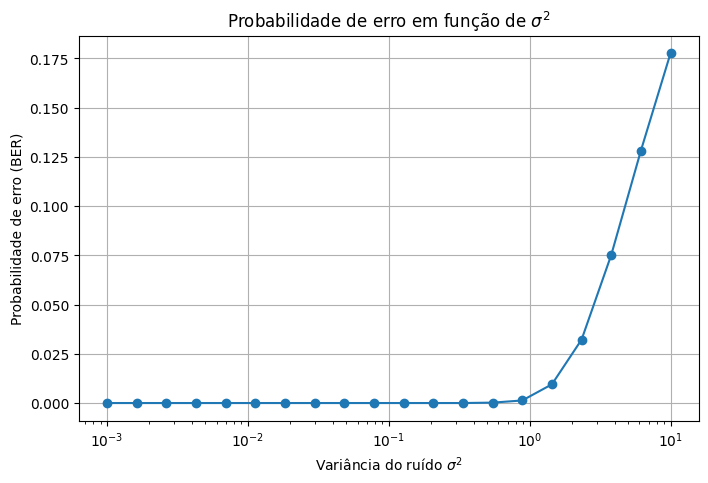

In [32]:
# -----------------------------
# Gráfico BER x sigma²
# -----------------------------

plt.figure(figsize=(8,5))

plt.semilogx(sigma2_values, ber_user1, marker='o')

plt.xlabel(r'Variância do ruído $\sigma^2$')
plt.ylabel('Probabilidade de erro (BER)')
plt.title(r'Probabilidade de erro em função de $\sigma^2$')

plt.grid(True)

plt.show()

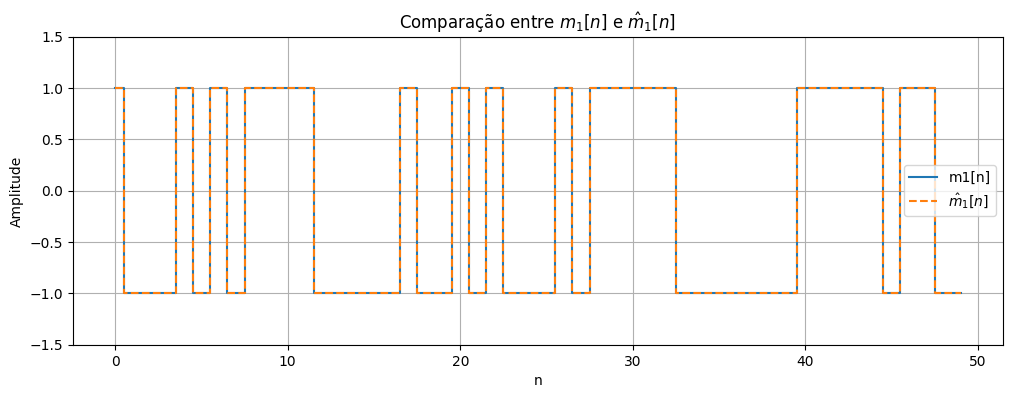

In [33]:
# -----------------------------
# Comparação visual
# -----------------------------

sigma2 = 0.1
sigma = np.sqrt(sigma2)

estimated = []

for i in range(50):

    y = x1[i] + x2[i] + x3[i]

    noise = np.random.normal(0, sigma, N)

    y = y + noise

    m_hat = recover_signal(y, c1)

    estimated.append(m_hat)

estimated = np.array(estimated)

plt.figure(figsize=(12,4))

plt.step(range(50), m1[:50], where='mid', label='m1[n]')
plt.step(range(50), estimated, where='mid', linestyle='--', label=r'$\hat{m}_1[n]$')

plt.ylim([-1.5, 1.5])

plt.xlabel('n')
plt.ylabel('Amplitude')

plt.title(r'Comparação entre $m_1[n]$ e $\hat{m}_1[n]$')

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
#Observa-se que a probabilidade de erro aumenta conforme a variância do ruído σ^2 cresce. Para valores pequenos de ruído, o sistema CDMA consegue recuperar corretamente os sinais transmitidos devido à ortogonalidade dos códigos de Hadamard, resultando em uma taxa de erro próxima de zero.
#Entretanto, à medida que a potência do ruído AWGN aumenta, o processo de correlação utilizado na recuperação dos sinais passa a sofrer maior interferência. Isso reduz a confiabilidade da detecção dos bits transmitidos, aumentando a probabilidade de erro.
#O gráfico BER × σ^2 evidencia que o desempenho do sistema é fortemente dependente da relação sinal-ruído. Mesmo com a utilização de códigos ortogonais, ruídos de alta potência degradam significativamente a recuperação dos sinais no receptor.

In [ ]:
#E)

### (e) Impact of Distorted Code Matrix at Receiver on $\hat{m}_k[n]$ (Mathematical Derivation)

Let's consider the scenario where the receiver does not have the original, perfectly orthogonal Hadamard codes. Instead, the code matrix available at the receiver, denoted as $\hat{\mathbf{C}} \in \mathbb{R}^{L \times L}$, is a noisy version of the true code matrix $\mathbf{C} \in \mathbb{R}^{L \times L}$.

$$\hat{\mathbf{C}} = \mathbf{C} + \mathbf{W}_{code}$$

where $\mathbf{W}_{code} \sim \mathcal{N}(\mathbf{0}_{L \times L}, \sigma_c^2 \mathbf{I}_L)$ is an AWGN matrix that causes distortion in the code available at the receiver. Here, $\sigma_c^2$ represents the variance of the noise affecting each element of the code matrix.

We are given that the channel noise $w[n]$ is zero, so the received signal $y[n]$ is simply the sum of the coded signals:

$$y[n] = \sum_{k=1}^{N} x_k[n]$$

Substituting $x_k[n] = m_k[n] \cdot c_k[n]$:

$$y[n] = \sum_{k=1}^{N} m_k[n] \cdot c_k[n]$$

In vectorial notation:

$$\mathbf{y} = \sum_{k=1}^{N} \mathbf{m}_k \odot \mathbf{c}_k$$

To recover the signal for user $j$, the receiver despreads the received signal $\mathbf{y}$ using its (distorted) code $\hat{\mathbf{c}}_j$, which is the $j$-th row of $\hat{\mathbf{C}}$. The element-wise recovery process is:

$$\hat{m}_j[n] = \text{sign}(y[n] \cdot \hat{c}_j[n])$$

Substitute the expressions for $y[n]$ and $\hat{c}_j[n]$:

$$\hat{m}_j[n] = \text{sign}\left( \left( \sum_{k=1}^{N} m_k[n] \cdot c_k[n] \right) \cdot (c_j[n] + w_{code_j}[n]) \right)$$

where $w_{code_j}[n]$ is the $n$-th element of the $j$-th row of $\mathbf{W}_{code}$.

Expand the product:

$$\hat{m}_j[n] = \text{sign}\left( \left( m_j[n] c_j[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] \right) (c_j[n] + w_{code_j}[n]) \right)$$

$$\hat{m}_j[n] = \text{sign}\left( m_j[n] c_j^2[n] + m_j[n] c_j[n] w_{code_j}[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] c_j[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] w_{code_j}[n] \right)$$

Since $c_j[n]$ can only be 1 or -1, $c_j^2[n] = 1$. So the equation simplifies to:

$$\hat{m}_j[n] = \text{sign}\left( m_j[n] + m_j[n] c_j[n] w_{code_j}[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] c_j[n] + \sum_{k \neq j}^{N} m_k[n] c_k[n] w_{code_j}[n] \right)$$

Let's analyze the terms within the `sign` function:

1.  **Desired Signal Term**: $m_j[n]$ - This is the original signal for user $j$, which we want to recover.

2.  **Noise Term due to Distorted Code (Self-Interference)**: $m_j[n] c_j[n] w_{code_j}[n]$ - This term represents noise introduced by the distortion in user $j$'s *own* code. Since $m_j[n]$ and $c_j[n]$ are $\pm 1$, this term has the same statistical properties as $w_{code_j}[n]$ (a Gaussian random variable with zero mean and variance $\sigma_c^2$).

3.  **Multi-User Interference (MUI) Term**: $\sum_{k \neq j}^{N} m_k[n] c_k[n] c_j[n]$ - This term represents interference from other users. In an ideal CDMA system with perfectly orthogonal codes, if we were using a correlation receiver over the entire sequence, this term would ideally sum to zero. However, with element-wise multiplication, this sum is not necessarily zero for each element $n$. If $c_k[n] c_j[n]$ is not always zero for $k \neq j$, then other users' signals will interfere. The orthogonality of Hadamard codes means that the *sum* over the full sequence $\sum_{n} c_k[n] c_j[n] = 0$ for $k \neq j$. But for any given $n$, $c_k[n] c_j[n]$ is either 1 or -1, thus contributing to interference.

4.  **Noise Term due to Distorted Code (Cross-Interference)**: $\sum_{k \neq j}^{N} m_k[n] c_k[n] w_{code_j}[n]$ - This term represents additional interference from other users due to the distortion in user $j$'s code. It's a product of other users' signals and the noise component of user $j$'s despreading code.

### Impact of Distortion on $\hat{m}_k[n]$:

*   **Loss of Orthogonality**: The most significant impact of a distorted code matrix $\hat{\mathbf{C}}$ is the **loss of perfect orthogonality**. When the receiver uses $\hat{\mathbf{c}}_j$ to despread, it no longer perfectly filters out the signals from other users. The terms $\sum_{k \neq j}^{N} m_k[n] c_k[n] c_j[n]$ and $\sum_{k \neq j}^{N} m_k[n] c_k[n] w_{code_j}[n]$ will not cancel out, leading to **Multi-User Interference (MUI)**.
*   **Additive Noise Component**: The term $m_j[n] c_j[n] w_{code_j}[n]$ acts as an additional noise component directly contaminating user $j$'s own signal. This effectively reduces the signal-to-noise ratio (SNR) for the intended user, even without channel noise.
*   **Decision Errors**: The presence of these interfering and noise terms means that the argument to the `sign` function can be different from the true $m_j[n]$. If the sum of these error terms is large enough to flip the sign of the original $m_j[n]$, a decision error will occur, leading to incorrect recovery of the bit.

In essence, distortion in the receiver's code matrix introduces both self-interference and cross-interference from other users, degrading the performance of the CDMA system by increasing the effective noise floor and leading to a higher probability of error in recovering the original signals, even in the absence of channel noise.

In [35]:
#F)
N = 8
num_users = 3
num_bits = 10000

# Variâncias do ruído do código
sigma2_values = np.logspace(-4, 0, 20)

# Matriz de Hadamard
H = hadamard(N)

# Códigos dos usuários
c1 = H[1]
c2 = H[2]
c3 = H[3]

codes = [c1, c2, c3]

In [36]:
# -----------------------------
# Mensagens binárias
# -----------------------------

m1 = np.random.choice([-1, 1], size=num_bits)
m2 = np.random.choice([-1, 1], size=num_bits)
m3 = np.random.choice([-1, 1], size=num_bits)

In [37]:
# -----------------------------
# Espalhamento
# -----------------------------

def spread_signal(message, code):
    return np.array([bit * code for bit in message])

x1 = spread_signal(m1, c1)
x2 = spread_signal(m2, c2)
x3 = spread_signal(m3, c3)

In [38]:
# -----------------------------
# Recuperação do sinal
# -----------------------------

def recover_signal(y, distorted_code):

    corr = np.dot(y, distorted_code)

    corr = corr / len(distorted_code)

    return 1 if corr >= 0 else -1

In [39]:
# -----------------------------
# BER x sigma²
# -----------------------------

ber = []

for sigma2 in sigma2_values:

    sigma = np.sqrt(sigma2)

    estimated_bits = []

    for i in range(num_bits):

        # -----------------------------
        # Canal sem ruído:
        # y[n] = x1 + x2 + x3
        # -----------------------------

        y = x1[i] + x2[i] + x3[i]

        # -----------------------------
        # Distorção no código do receptor
        # -----------------------------

        W = np.random.normal(0, sigma, N)

        c1_distorted = c1 + W

        # Recuperação
        m_hat = recover_signal(y, c1_distorted)

        estimated_bits.append(m_hat)

    estimated_bits = np.array(estimated_bits)

    # Probabilidade de erro
    errors = np.sum(estimated_bits != m1)

    ber_value = errors / num_bits

    ber.append(ber_value)

    print(f"sigma² = {sigma2:.5f} -> BER = {ber_value:.6f}")

sigma² = 0.00010 -> BER = 0.000000
sigma² = 0.00016 -> BER = 0.000000
sigma² = 0.00026 -> BER = 0.000000
sigma² = 0.00043 -> BER = 0.000000
sigma² = 0.00070 -> BER = 0.000000
sigma² = 0.00113 -> BER = 0.000000
sigma² = 0.00183 -> BER = 0.000000
sigma² = 0.00298 -> BER = 0.000000
sigma² = 0.00483 -> BER = 0.000000
sigma² = 0.00785 -> BER = 0.000000
sigma² = 0.01274 -> BER = 0.000000
sigma² = 0.02069 -> BER = 0.000000
sigma² = 0.03360 -> BER = 0.000000
sigma² = 0.05456 -> BER = 0.000000
sigma² = 0.08859 -> BER = 0.000000
sigma² = 0.14384 -> BER = 0.000000
sigma² = 0.23357 -> BER = 0.000800
sigma² = 0.37927 -> BER = 0.003500
sigma² = 0.61585 -> BER = 0.016400
sigma² = 1.00000 -> BER = 0.050800


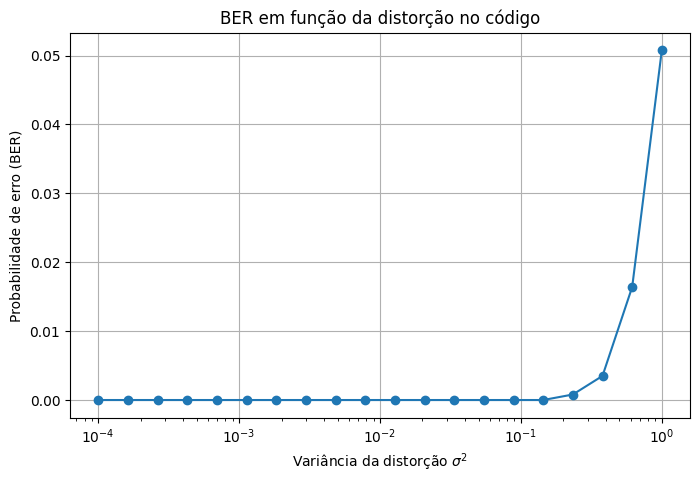

In [40]:
# -----------------------------
# Gráfico
# -----------------------------

plt.figure(figsize=(8,5))

plt.semilogx(sigma2_values, ber, marker='o')

plt.xlabel(r'Variância da distorção $\sigma^2$')
plt.ylabel('Probabilidade de erro (BER)')

plt.title(r'BER em função da distorção no código')

plt.grid(True)

plt.show()

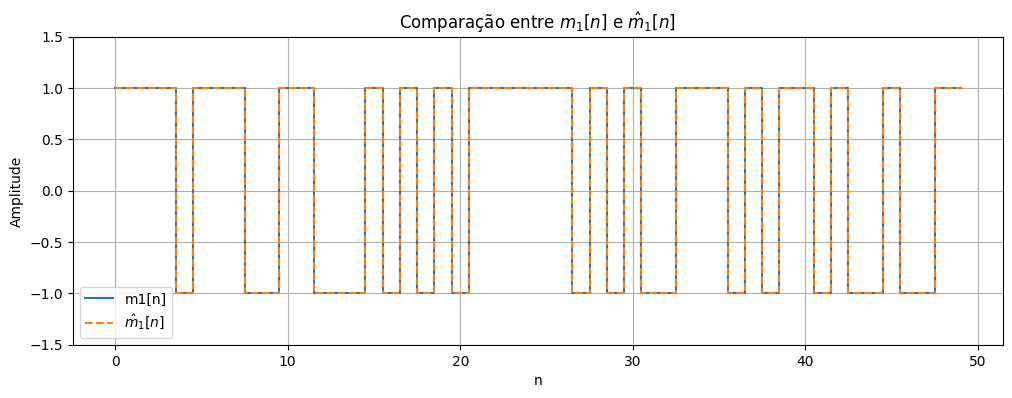

In [41]:
# -----------------------------
# Comparação visual
# -----------------------------

sigma2 = 0.1
sigma = np.sqrt(sigma2)

estimated = []

for i in range(50):

    y = x1[i] + x2[i] + x3[i]

    W = np.random.normal(0, sigma, N)

    c1_distorted = c1 + W

    m_hat = recover_signal(y, c1_distorted)

    estimated.append(m_hat)

plt.figure(figsize=(12,4))

plt.step(range(50), m1[:50], where='mid', label='m1[n]')

plt.step(range(50), estimated,
         where='mid',
         linestyle='--',
         label=r'$\hat{m}_1[n]$')

plt.ylim([-1.5, 1.5])

plt.xlabel('n')
plt.ylabel('Amplitude')

plt.title(r'Comparação entre $m_1[n]$ e $\hat{m}_1[n]$')

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
#Observa-se que a probabilidade de erro aumenta conforme cresce a variância da distorção aplicada ao código disponível no receptor. Isso ocorre porque a perturbação introduzida em C reduz a ortogonalidade entre os códigos de Hadamard, prejudicando o processo de separação dos usuários.
#Mesmo na ausência de ruído no canal (w[n]=0), a utilização de códigos distorcidos provoca interferência entre usuários, fazendo com que o processo de correlação não recupere perfeitamente os símbolos transmitidos.
#Para valores pequenos de σ^2, os códigos ainda permanecem próximos dos originais e o sistema apresenta baixa taxa de erro. Entretanto, à medida que a distorção aumenta, a interferência entre usuários se torna mais significativa, elevando rapidamente a probabilidade de erro na detecção dos bits.

In [ ]:
#Exercício Prático 2

In [ ]:
#Teorica

In [ ]:
#Exercício Prático 3

In [43]:
import numpy as np
import matplotlib.pyplot as plt

N = 2000                                             # Signal length
t = np.arange(N + 1)                                 # Time values
x = np.zeros_like(t, dtype=np.float64)               # Initialize x as float to allow for sin wave additions

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000]) # Initial position for each sinusoid function
T_sin = np.array([100, 40, 20, 10, 5])               # Sampling period of each sinusoid function

for i in range(5):
    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.sin(2*np.pi*t_segment_values/T_sin[i])

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    relative_end_offset = int(T_imp[i] / 2)
    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (np.sin(2 *np.pi*t_segment_values/T_imp[i]))**2

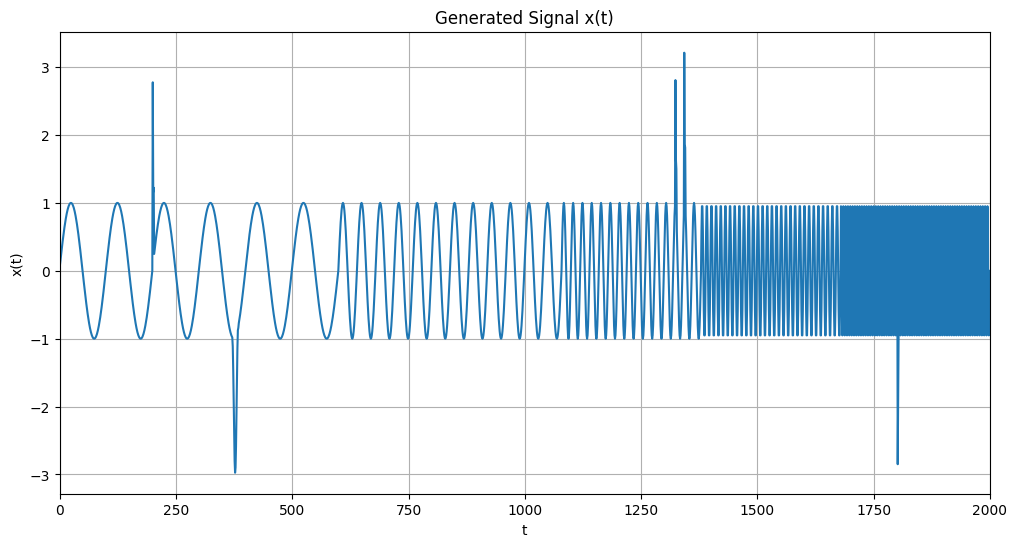

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Generated Signal x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.xlim(0, N)
plt.grid(True)
plt.show()

In [45]:
!pip install PyWavelets

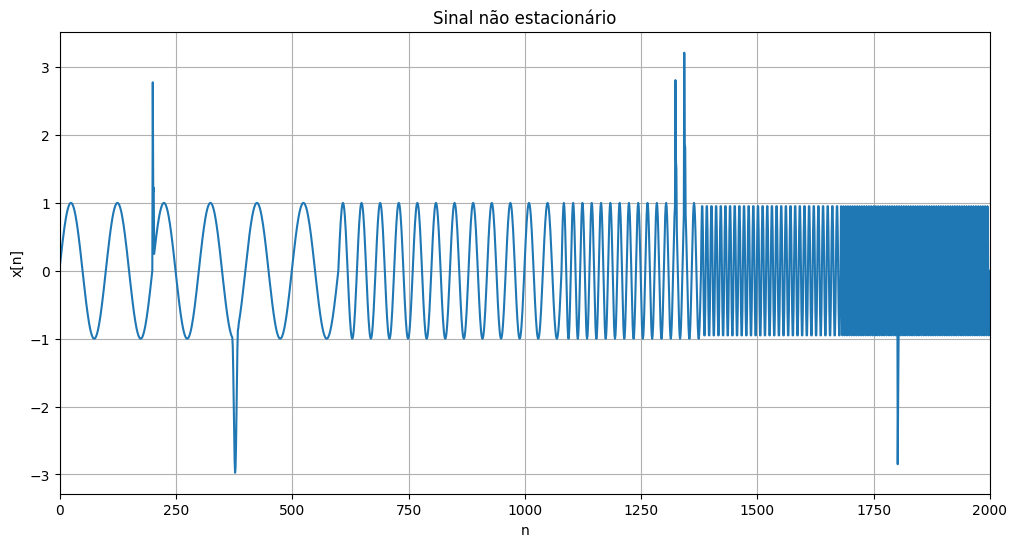

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pywt
# -----------------------------
# Geração do sinal
# -----------------------------

N = 2000

t = np.arange(N + 1)

x = np.zeros_like(t, dtype=np.float64)

# Componentes senoidais
pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000])

T_sin = np.array([100, 40, 20, 10, 5])

for i in range(5):

    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m

    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.sin(
        2*np.pi*t_segment_values/T_sin[i]
    )

# Componentes impulsivas
amp_imp = np.array([3, -2, 2, 2.5, -2.5])

pos_imp = np.array([200, 372, 1324, 1343, 1802])

T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):

    m = pos_imp[i]

    relative_end_offset = int(T_imp[i] / 2)

    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1

    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (
        np.sin(
            2*np.pi*t_segment_values/T_imp[i]
        )
    )**2

# Visualização do sinal
plt.figure(figsize=(12,6))

plt.plot(t, x)

plt.title('Sinal não estacionário')

plt.xlabel('n')

plt.ylabel('x[n]')

plt.xlim(0, N)

plt.grid(True)

plt.show()

In [54]:
# -----------------------------
# Conversão para PyTorch
# -----------------------------

signal_torch = torch.tensor(
    x,
    dtype=torch.float32
)

signal_torch = signal_torch.view(1,1,-1)

In [55]:
# -----------------------------
# Wavelet utilizada
# -----------------------------

wavelet = pywt.Wavelet('bior4.4')

print(wavelet)

Wavelet bior4.4
  Family name:    Biorthogonal
  Short name:     bior
  Filters length: 10
  Orthogonal:     False
  Biorthogonal:   True
  Symmetry:       symmetric
  DWT:            True
  CWT:            False


In [56]:
# -----------------------------
# Filtros de análise e síntese
# -----------------------------

dec_lo = wavelet.dec_lo
dec_hi = wavelet.dec_hi

rec_lo = wavelet.rec_lo
rec_hi = wavelet.rec_hi

print('===================================')
print('Filtro passa-baixa de análise')
print('===================================')

print(np.array(dec_lo))

print('\n===================================')
print('Filtro passa-alta de análise')
print('===================================')

print(np.array(dec_hi))

print('\n===================================')
print('Filtro passa-baixa de síntese')
print('===================================')

print(np.array(rec_lo))

print('\n===================================')
print('Filtro passa-alta de síntese')
print('===================================')

print(np.array(rec_hi))

Filtro passa-baixa de análise
[ 0.          0.03782846 -0.02384947 -0.1106244   0.37740286  0.85269868
  0.37740286 -0.1106244  -0.02384947  0.03782846]

Filtro passa-alta de análise
[-0.         -0.06453888  0.04068942  0.41809227 -0.78848562  0.41809227
  0.04068942 -0.06453888 -0.          0.        ]

Filtro passa-baixa de síntese
[ 0.         -0.06453888 -0.04068942  0.41809227  0.78848562  0.41809227
 -0.04068942 -0.06453888  0.          0.        ]

Filtro passa-alta de síntese
[ 0.         -0.03782846 -0.02384947  0.1106244   0.37740286 -0.85269868
  0.37740286  0.1106244  -0.02384947 -0.03782846]


In [57]:
# -----------------------------
# Conversão dos filtros
# -----------------------------

low_filter = torch.tensor(
    dec_lo,
    dtype=torch.float32
).view(1,1,-1)

high_filter = torch.tensor(
    dec_hi,
    dtype=torch.float32
).view(1,1,-1)

In [58]:
# -----------------------------
# Decomposição Wavelet
# -----------------------------

approx = torch.nn.functional.conv1d(
    signal_torch,
    low_filter,
    stride=2,
    padding=len(dec_lo)//2
)

detail = torch.nn.functional.conv1d(
    signal_torch,
    high_filter,
    stride=2,
    padding=len(dec_hi)//2
)

# Conversão para numpy
approx = approx.squeeze().detach().numpy()

detail = detail.squeeze().detach().numpy()

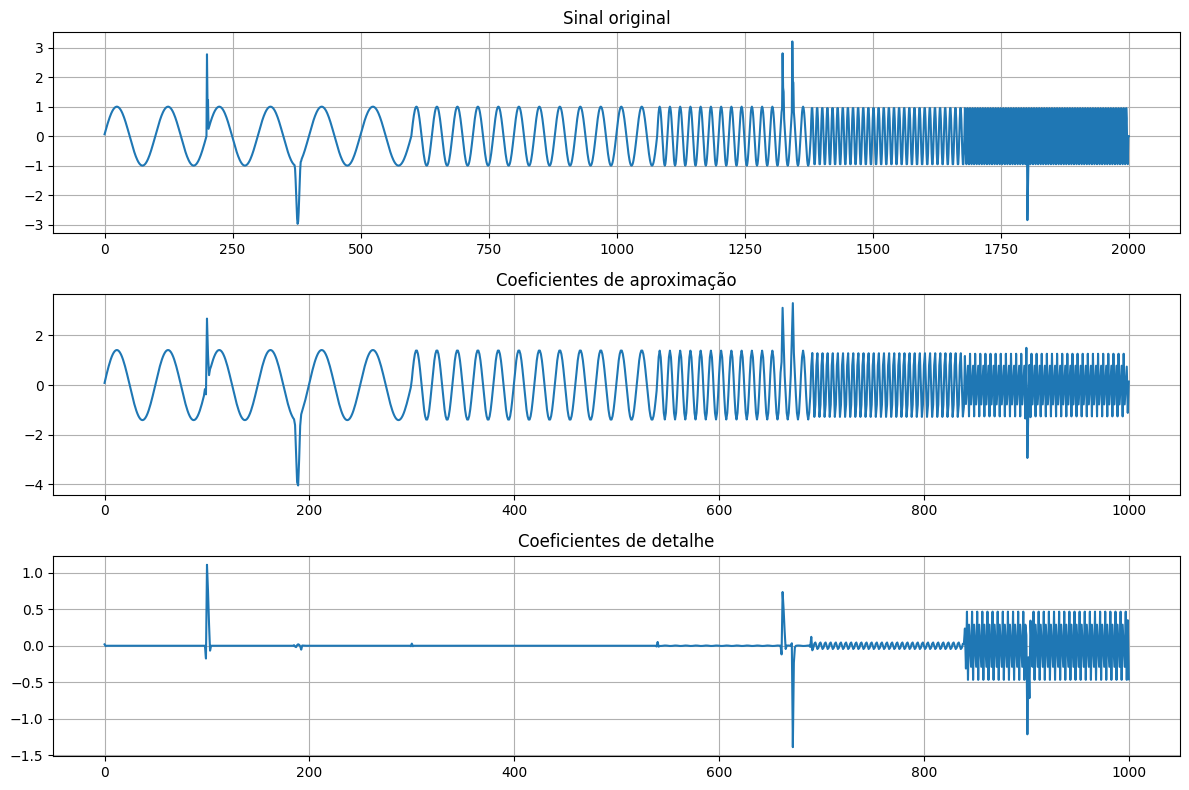

In [59]:
# -----------------------------
# Resultados
# -----------------------------

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)

plt.plot(x)

plt.title('Sinal original')

plt.grid(True)

plt.subplot(3,1,2)

plt.plot(approx)

plt.title('Coeficientes de aproximação')

plt.grid(True)

plt.subplot(3,1,3)

plt.plot(detail)

plt.title('Coeficientes de detalhe')

plt.grid(True)

plt.tight_layout()

plt.show()

In [61]:
#C)
# -----------------------------
# Decomposição em 5 níveis
# -----------------------------

coeffs = pywt.wavedec(
    x,
    wavelet='bior4.4',
    level=5
)

# Coeficientes
cA5 = coeffs[0]

cD5 = coeffs[1]
cD4 = coeffs[2]
cD3 = coeffs[3]
cD2 = coeffs[4]
cD1 = coeffs[5]

In [62]:
# -----------------------------
# Coeficientes
# -----------------------------

print("===================================")
print("Coeficientes de aproximação cA5")
print("===================================")

print(cA5)

print("\n===================================")
print("Coeficientes de detalhe")
print("===================================")

print("\ncD5:\n", cD5)

print("\ncD4:\n", cD4)

print("\ncD3:\n", cD3)

print("\ncD2:\n", cD2)

print("\ncD1:\n", cD1)

Coeficientes de aproximação cA5
[ 8.00233110e-01  1.13180530e+00  1.01772490e+00  9.49320713e-01
  2.33941145e+00  3.82229212e+00 -4.74169563e+00  3.21519192e-01
  4.51049354e+00 -4.26388157e+00 -5.06822951e-02  4.95149557e+00
 -3.22501671e+00 -2.16321583e+00  5.08429920e+00 -2.81203837e+00
 -4.94598714e+00  5.10300495e+00 -9.89659438e-01 -4.12979309e+00
  4.47388814e+00  3.22046332e-01 -4.47457672e+00  1.16805647e+00
  1.32192882e-01 -1.62067182e-01 -3.36902116e-01 -5.33639391e-02
  3.03945923e-01  2.41212851e-01 -1.54868183e-01 -3.36926652e-01
 -5.33639391e-02  3.03945923e-01  2.41211609e-01 -1.60976229e-01
 -4.65206732e-01  2.83628268e-01 -6.73650763e-01  3.29449713e-01
 -2.64346548e-01  9.94782263e-02  9.90817180e-02 -2.45867043e-01
  2.94066404e-01  1.85816679e-01  1.11074591e+00 -5.86070406e-01
  1.70256224e-01 -2.99884796e-02 -2.08271999e-02 -1.33296688e-02
  1.33296688e-02  2.15947620e-02 -4.48910466e-03 -8.57442859e-03
 -1.23688465e-01 -1.85320938e-02 -3.79174031e-02  9.017022

In [63]:
# -----------------------------
# Eixos temporais normalizados
# -----------------------------

t_original = np.linspace(0, 1, len(x))

t_cA5 = np.linspace(0, 1, len(cA5))

t_cD5 = np.linspace(0, 1, len(cD5))

t_cD4 = np.linspace(0, 1, len(cD4))

t_cD3 = np.linspace(0, 1, len(cD3))

t_cD2 = np.linspace(0, 1, len(cD2))

t_cD1 = np.linspace(0, 1, len(cD1))

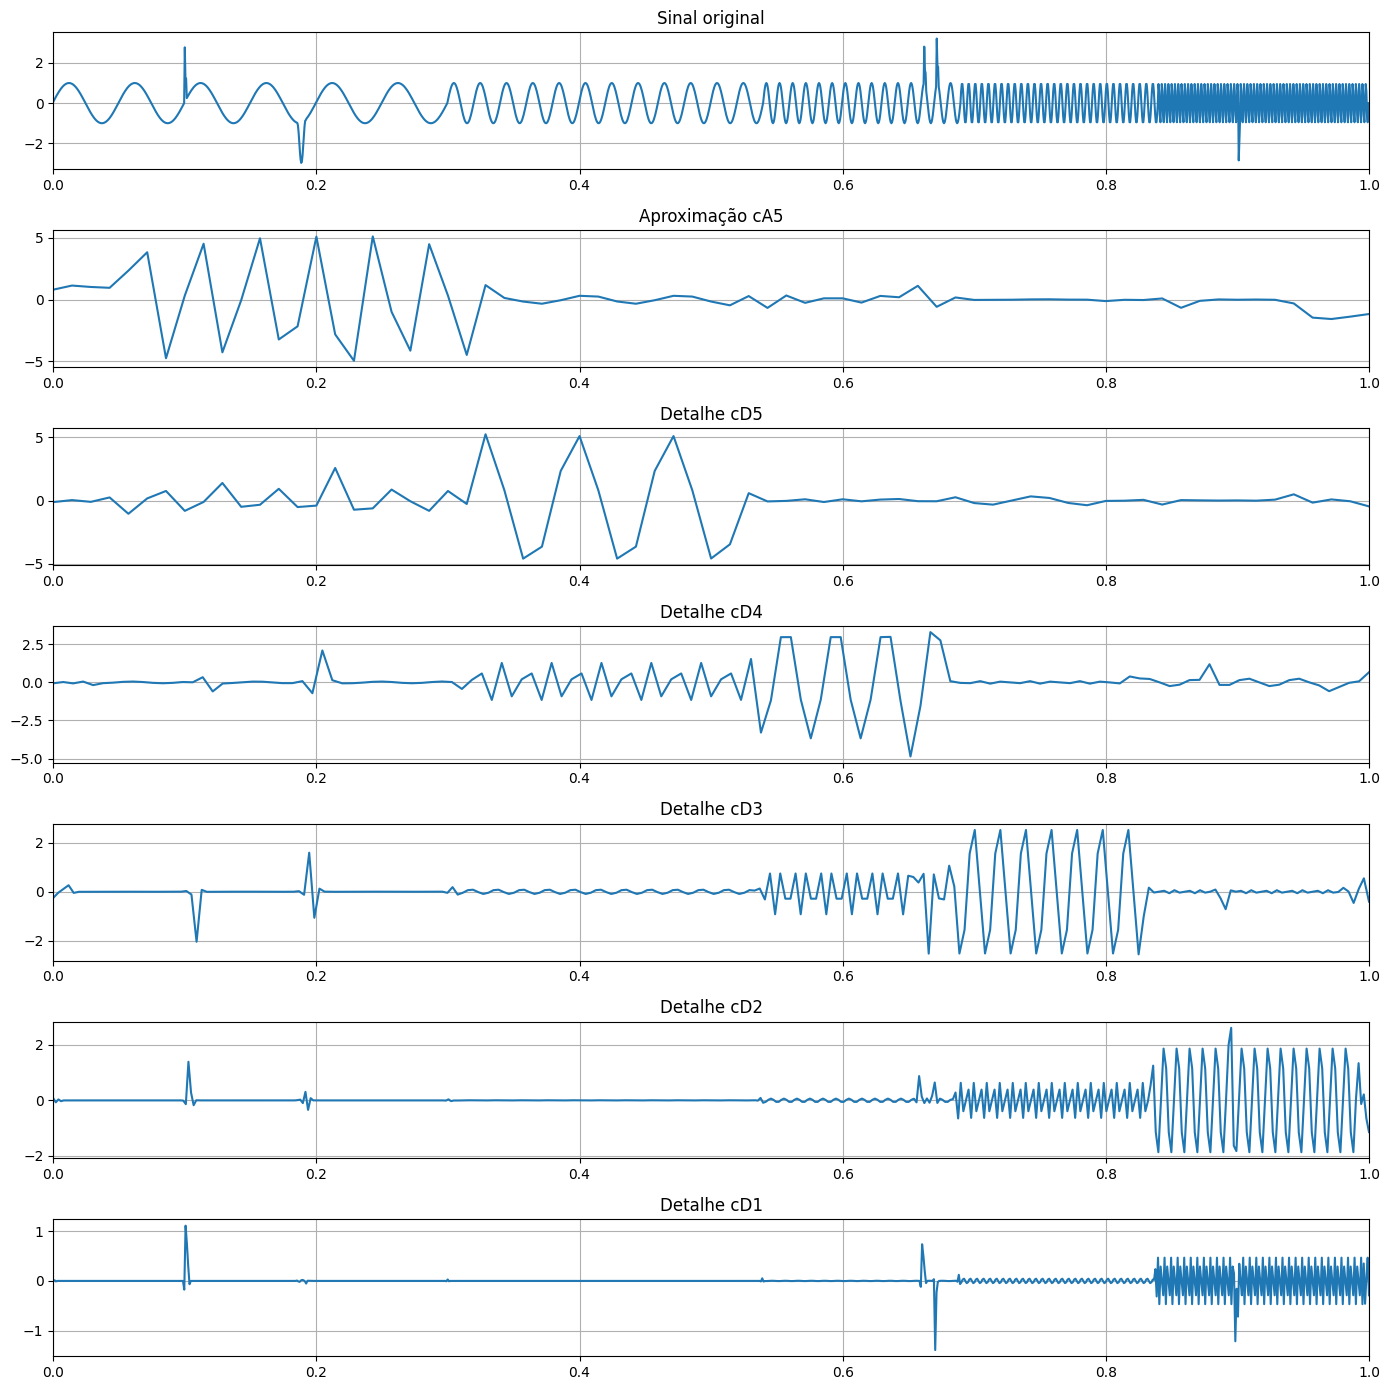

In [64]:
# -----------------------------
# Subfaixas Wavelet
# -----------------------------

plt.figure(figsize=(14,14))

# Sinal original
plt.subplot(7,1,1)

plt.plot(t_original, x)

plt.title('Sinal original')

plt.xlim(0,1)

plt.grid(True)

# Aproximação
plt.subplot(7,1,2)

plt.plot(t_cA5, cA5)

plt.title('Aproximação cA5')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D5
plt.subplot(7,1,3)

plt.plot(t_cD5, cD5)

plt.title('Detalhe cD5')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D4
plt.subplot(7,1,4)

plt.plot(t_cD4, cD4)

plt.title('Detalhe cD4')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D3
plt.subplot(7,1,5)

plt.plot(t_cD3, cD3)

plt.title('Detalhe cD3')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D2
plt.subplot(7,1,6)

plt.plot(t_cD2, cD2)

plt.title('Detalhe cD2')

plt.xlim(0,1)

plt.grid(True)

# Detalhe D1
plt.subplot(7,1,7)

plt.plot(t_cD1, cD1)

plt.title('Detalhe cD1')

plt.xlim(0,1)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
#A transformada wavelet em cinco estágios permitiu decompor o sinal em diferentes subfaixas de frequência, separando componentes de baixa e alta frequência em múltiplas escalas.
#Os coeficientes de aproximação cA5 representam as componentes de baixa frequência do sinal, preservando o comportamento global e as tendências mais lentas das componentes senoidais. Já os coeficientes de detalhe cD1 até cD5 representam componentes de frequência progressivamente menores.Observa-se que os detalhes de níveis baixos, principalmente cD1 e cD2, destacam os impulsos e variações rápidas do sinal, enquanto os níveis mais altos apresentam componentes mais suaves e associadas às mudanças lentas de frequência.
#A normalização do eixo temporal permitiu comparar diretamente as diferentes subfaixas ao longo do tempo, mesmo após os processos de dizimação realizados em cada estágio da decomposição wavelet. Isso facilita a visualização da localização temporal das componentes presentes no sinal não estacionário.

In [ ]:
#Exercício Prático 4

In [66]:
from google.colab import files

uploaded = files.upload()

Saving leleccum.mat to leleccum.mat


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
# -----------------------------
# Carregamento do sinal
# -----------------------------

data = loadmat('leleccum.mat')

# Nome da variável dentro do arquivo
signal = data['leleccum']

# Remove dimensões extras
signal = signal.squeeze()

print("Tamanho do sinal:", len(signal))

Tamanho do sinal: 4320


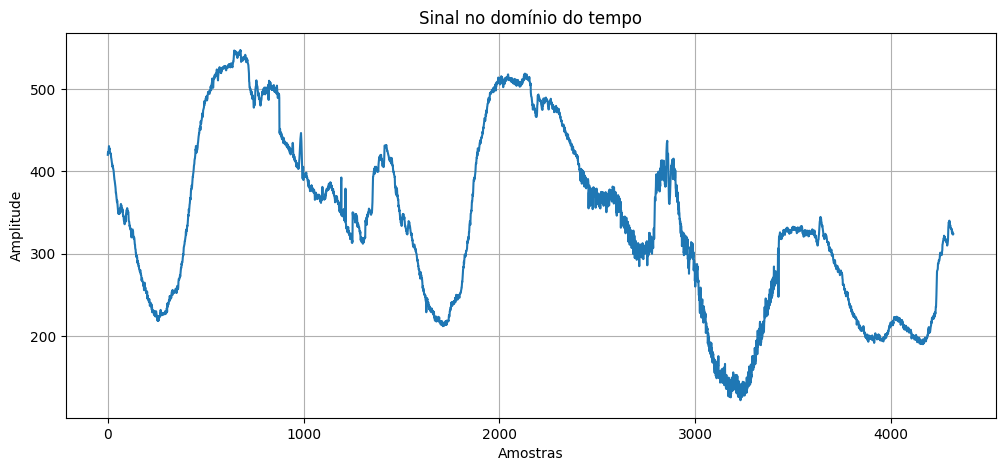

In [68]:
# -----------------------------
# Sinal no tempo
# -----------------------------

n = np.arange(len(signal))

plt.figure(figsize=(12,5))

plt.plot(n, signal)

plt.title('Sinal no domínio do tempo')

plt.xlabel('Amostras')

plt.ylabel('Amplitude')

plt.grid(True)

plt.show()

In [69]:
# -----------------------------
# FFT do sinal
# -----------------------------

N = len(signal)

X = np.fft.fft(signal)

# Magnitude normalizada
X_mag = np.abs(X)/N

# Frequências normalizadas
freq = np.fft.fftfreq(N)

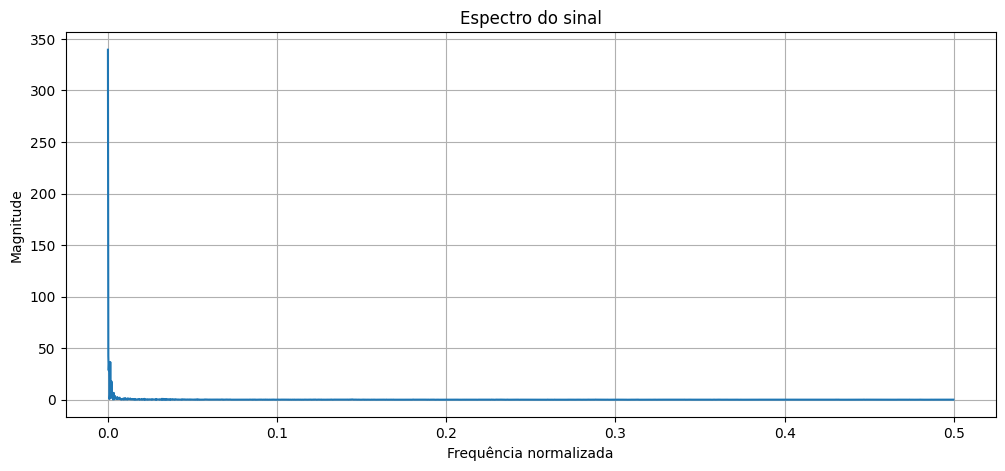

In [70]:
# -----------------------------
# Espectro do sinal
# -----------------------------

plt.figure(figsize=(12,5))

plt.plot(freq[:N//2], X_mag[:N//2])

plt.title('Espectro do sinal')

plt.xlabel('Frequência normalizada')

plt.ylabel('Magnitude')

plt.grid(True)

plt.show()

In [71]:
#B)
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat
# -----------------------------
# Carregamento do arquivo
# -----------------------------

data = loadmat('leleccum.mat')

# Mostra variáveis disponíveis
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'leleccum'])


In [72]:
signal = data['leleccum'].squeeze()

print("Tamanho do sinal:", len(signal))

Tamanho do sinal: 4320


In [73]:
# -----------------------------
# Wavelet db4
# -----------------------------

wavelet = pywt.Wavelet('db4')

print(wavelet)

Wavelet db4
  Family name:    Daubechies
  Short name:     db
  Filters length: 8
  Orthogonal:     True
  Biorthogonal:   True
  Symmetry:       asymmetric
  DWT:            True
  CWT:            False


In [74]:
# -----------------------------
# Filtros de análise e síntese
# -----------------------------

dec_lo = wavelet.dec_lo
dec_hi = wavelet.dec_hi

rec_lo = wavelet.rec_lo
rec_hi = wavelet.rec_hi

print('===================================')
print('Filtro passa-baixa de análise')
print('===================================')

print(np.array(dec_lo))

print('\n===================================')
print('Filtro passa-alta de análise')
print('===================================')

print(np.array(dec_hi))

print('\n===================================')
print('Filtro passa-baixa de síntese')
print('===================================')

print(np.array(rec_lo))

print('\n===================================')
print('Filtro passa-alta de síntese')
print('===================================')

print(np.array(rec_hi))

Filtro passa-baixa de análise
[-0.0105974   0.03288301  0.03084138 -0.18703481 -0.02798377  0.63088077
  0.71484657  0.23037781]

Filtro passa-alta de análise
[-0.23037781  0.71484657 -0.63088077 -0.02798377  0.18703481  0.03084138
 -0.03288301 -0.0105974 ]

Filtro passa-baixa de síntese
[ 0.23037781  0.71484657  0.63088077 -0.02798377 -0.18703481  0.03084138
  0.03288301 -0.0105974 ]

Filtro passa-alta de síntese
[-0.0105974  -0.03288301  0.03084138  0.18703481 -0.02798377 -0.63088077
  0.71484657 -0.23037781]


In [75]:
# -----------------------------
# Decomposição wavelet
# -----------------------------

cA, cD = pywt.dwt(signal, 'db4')

print("Tamanho da aproximação:", len(cA))
print("Tamanho do detalhe:", len(cD))

Tamanho da aproximação: 2163
Tamanho do detalhe: 2163


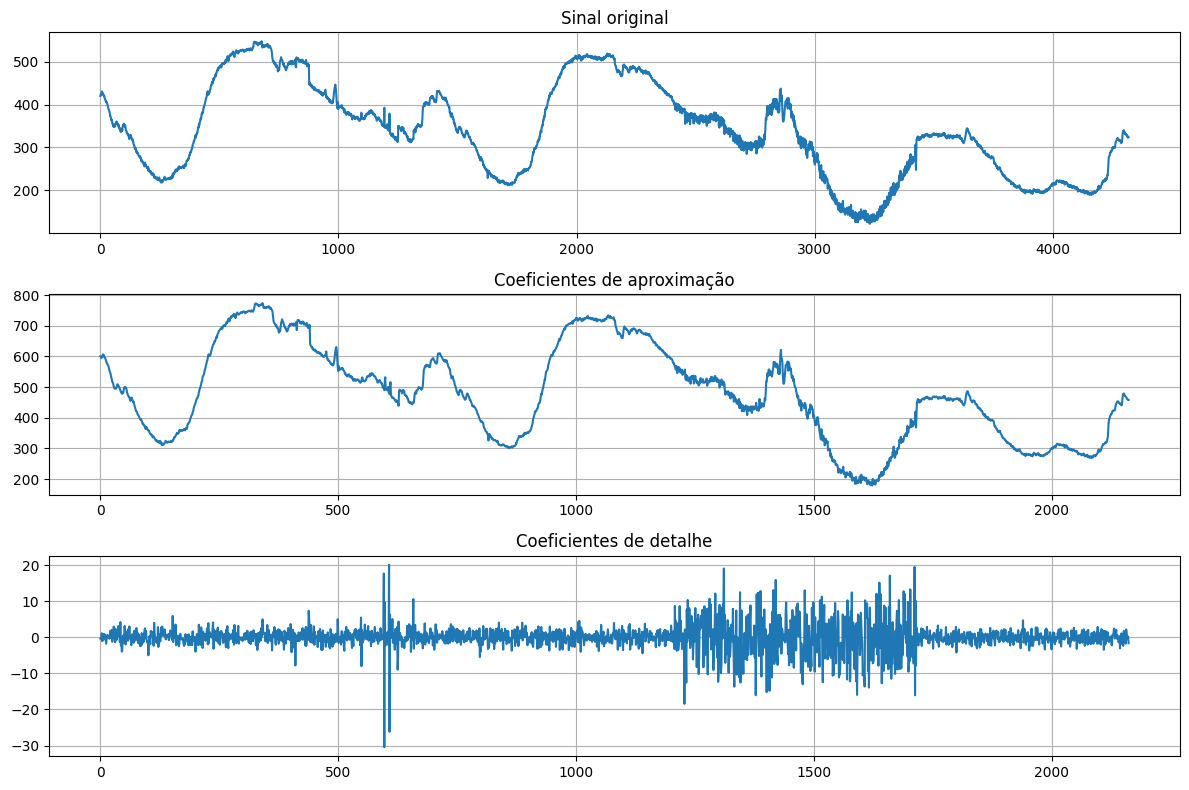

In [76]:
# -----------------------------
# Resultados
# -----------------------------

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)

plt.plot(signal)

plt.title('Sinal original')

plt.grid(True)

plt.subplot(3,1,2)

plt.plot(cA)

plt.title('Coeficientes de aproximação')

plt.grid(True)

plt.subplot(3,1,3)

plt.plot(cD)

plt.title('Coeficientes de detalhe')

plt.grid(True)

plt.tight_layout()

plt.show()